## Parte 1: Setup Rápido - Dataset Ames Housing

### Paso 1.1: Setup Rápido - Cargar y Preprocesar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Configuración
np.random.seed(42)
plt.style.use('default')
sns.set_palette("husl")

print("=" * 80)
print("ASSIGNMENT UT3-10: PCA y Feature Selection - Ames Housing Dataset")
print("=" * 80)

# ========== FUNCIÓN DE CARGA Y PREPROCESAMIENTO RÁPIDO ==========
def quick_load_and_preprocess_ames(filepath='train.csv'):
    """
    Carga y preprocesa Ames Housing en un solo paso
    (Ya hiciste esto en tareas anteriores, aquí es versión simplificada)
    """
    print("\n🏠 CARGANDO Y PREPROCESANDO AMES HOUSING...")

    # Cargar dataset
    df = pd.read_csv(filepath)
    print(f"✅ Dataset cargado: {df.shape[0]:,} casas, {df.shape[1]} columnas")

    # Eliminar 'Id' (no predictivo)
    df = df.drop('Id', axis=1, errors='ignore')

    # Identificar tipos de variables
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    # Remover target de features
    if 'SalePrice' in numerical_cols:
        numerical_cols.remove('SalePrice')

    print(f"✅ Features numéricas: {len(numerical_cols)}")
    print(f"✅ Features categóricas: {len(categorical_cols)}")

    # Imputar valores faltantes
    num_imputer = SimpleImputer(strategy='median')
    df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

    print(f"✅ Missing values imputados")

    # Label encoding para categóricas
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    print(f"✅ Categóricas encoded")

    # Separar X y y
    X = df.drop('SalePrice', axis=1)
    y = df['SalePrice']

    print(f"\n✅ DATASET LISTO:")
    print(f"   X shape: {X.shape} ({X.shape[1]} features)")
    print(f"   y shape: {y.shape}")
    print(f"   Precio promedio: ${y.mean():,.0f}")
    print(f"   Precio mediana: ${y.median():,.0f}")

    return X, y, X.columns.tolist()

# ========== EJECUTAR CARGA RÁPIDA ==========
# TODO: Completa con el path correcto
X, y, feature_names = quick_load_and_preprocess_ames('AmesHousing.csv')

print(f"\n📊 RESUMEN DEL DATASET:")
print(f"   Total features: {X.shape[1]}")
print(f"   Total casas: {X.shape[0]:,}")
print(f"   Ejemplos de features: {feature_names[:10]}")

ASSIGNMENT UT3-10: PCA y Feature Selection - Ames Housing Dataset

🏠 CARGANDO Y PREPROCESANDO AMES HOUSING...
✅ Dataset cargado: 2,930 casas, 82 columnas
✅ Features numéricas: 38
✅ Features categóricas: 43
✅ Missing values imputados
✅ Categóricas encoded

✅ DATASET LISTO:
   X shape: (2930, 81) (81 features)
   y shape: (2930,)
   Precio promedio: $180,796
   Precio mediana: $160,000

📊 RESUMEN DEL DATASET:
   Total features: 81
   Total casas: 2,930
   Ejemplos de features: ['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour']


## Parte 2: PCA - Análisis de Componentes Principales

### Paso 2.1: Estandarización (Crítico para PCA)

In [6]:
from sklearn.preprocessing import StandardScaler

# ========== ESTANDARIZACIÓN ==========
print("=== ESTANDARIZACIÓN DE FEATURES ===")
print("⚠️ PCA es sensible a escala. SIEMPRE estandarizar antes de PCA.")

# TODO: Estandarizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificar estandarización: mean ≈ 0, std ≈ 1
print(f"\n✅ Mean después de scaling: {X_scaled.mean():.6f} (esperado: ~0)")
print(f"✅ Std después de scaling: {X_scaled.std():.6f} (esperado: ~1)")

# Verificar shape
print(f"✅ X_scaled shape: {X_scaled.shape}")

# Comparar antes vs después
print(f"\n=== COMPARACIÓN ANTES vs DESPUÉS ===")
print(f"Antes - Mean GrLivArea: {X['Gr Liv Area'].mean():.0f}, Std: {X['Gr Liv Area'].std():.0f}")
print(f"Después - Mean GrLivArea: {X_scaled[:, X.columns.get_loc('Gr Liv Area')].mean():.6f}, Std: {X_scaled[:, X.columns.get_loc('Gr Liv Area')].std():.6f}")

=== ESTANDARIZACIÓN DE FEATURES ===
⚠️ PCA es sensible a escala. SIEMPRE estandarizar antes de PCA.

✅ Mean después de scaling: -0.000000 (esperado: ~0)
✅ Std después de scaling: 1.000000 (esperado: ~1)
✅ X_scaled shape: (2930, 81)

=== COMPARACIÓN ANTES vs DESPUÉS ===
Antes - Mean GrLivArea: 1500, Std: 506
Después - Mean GrLivArea: 0.000000, Std: 1.000000


### Paso 2.2: Aplicar PCA Completo (80 Componentes)

In [7]:
from sklearn.decomposition import PCA
import time

# ========== APLICAR PCA SIN RESTRICCIONES ==========
print("\n=== APLICANDO PCA ===")
print("⏱️ Esto puede tomar 10-20 segundos con 80 features...")

start_time = time.time()

# TODO: Aplicar PCA sin restricción de componentes
pca = PCA()  # Sin n_components = todos los componentes posibles
X_pca = pca.fit_transform(X_scaled)

elapsed_time = time.time() - start_time
print(f"✅ PCA completado en {elapsed_time:.2f} segundos")

# ========== ANALIZAR VARIANZA EXPLICADA ==========
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"\n=== ANÁLISIS DE COMPONENTES PRINCIPALES ===")
print(f"Total de componentes generados: {X_pca.shape[1]}")
print(f"\nVarianza explicada por componentes principales:")
print(f"  PC1: {explained_variance[0]:.3%} (¡la más importante!)")
print(f"  PC2: {explained_variance[1]:.3%}")
print(f"  PC3: {explained_variance[2]:.3%}")
print(f"  PC4: {explained_variance[3]:.3%}")
print(f"  PC5: {explained_variance[4]:.3%}")

# TODO: Top 10 componentes
print("\n=== TOP 10 COMPONENTES ===")
for i in range(min(10, len(explained_variance))):
    print(f"PC{i+1:2d}: Individual {explained_variance[i]:6.3%} | Acumulada {cumulative_variance[i]:6.3%}")


=== APLICANDO PCA ===
⏱️ Esto puede tomar 10-20 segundos con 80 features...
✅ PCA completado en 0.02 segundos

=== ANÁLISIS DE COMPONENTES PRINCIPALES ===
Total de componentes generados: 81

Varianza explicada por componentes principales:
  PC1: 13.409% (¡la más importante!)
  PC2: 4.956%
  PC3: 4.709%
  PC4: 3.690%
  PC5: 2.974%

=== TOP 10 COMPONENTES ===
PC 1: Individual 13.409% | Acumulada 13.409%
PC 2: Individual 4.956% | Acumulada 18.365%
PC 3: Individual 4.709% | Acumulada 23.074%
PC 4: Individual 3.690% | Acumulada 26.765%
PC 5: Individual 2.974% | Acumulada 29.739%
PC 6: Individual 2.727% | Acumulada 32.466%
PC 7: Individual 2.550% | Acumulada 35.017%
PC 8: Individual 2.404% | Acumulada 37.420%
PC 9: Individual 2.239% | Acumulada 39.659%
PC10: Individual 2.121% | Acumulada 41.780%


### Paso 2.3: Scree Plot y Decisión de Dimensionalidad


=== SCREE PLOT: VISUALIZACIÓN DE VARIANZA ===


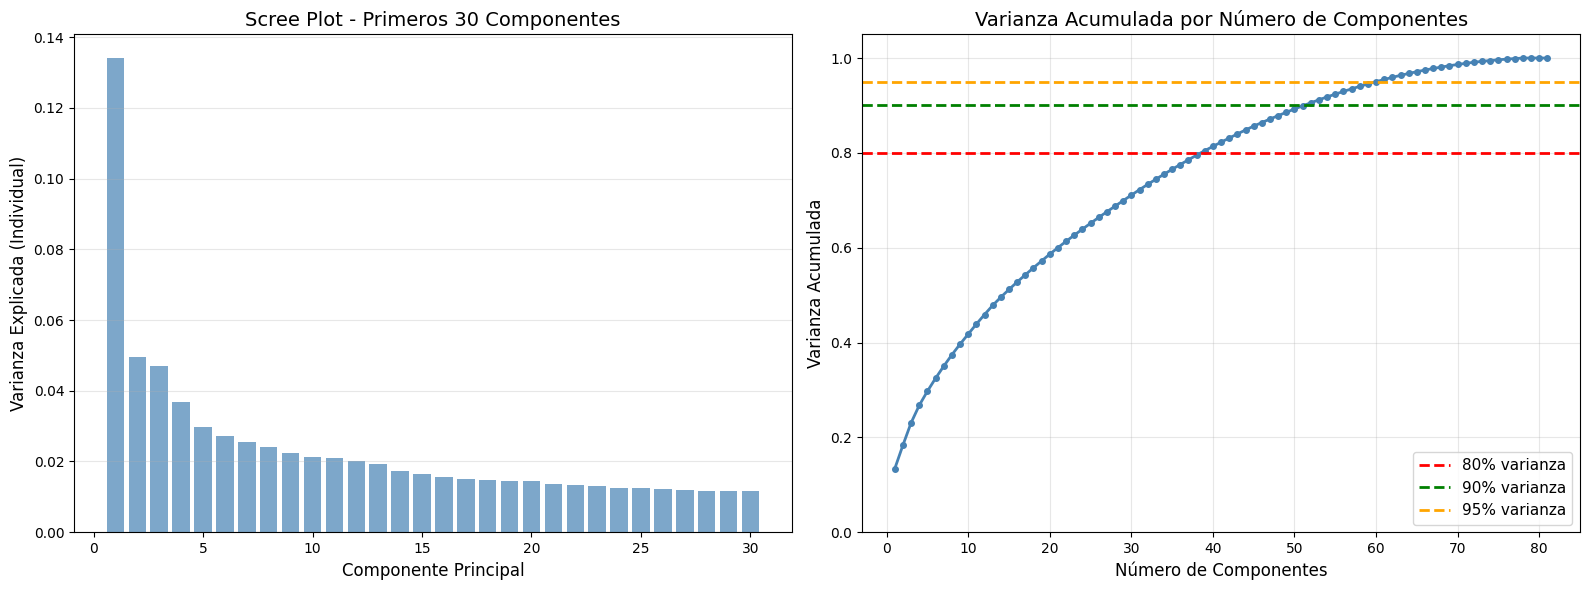


=== DECISIÓN: ¿CUÁNTOS COMPONENTES NECESITAMOS? ===
📊 Para 80% de varianza: 39 componentes
📊 Para 90% de varianza: 52 componentes
📊 Para 95% de varianza: 60 componentes

🎯 IMPACTO DE REDUCCIÓN DIMENSIONAL:
   Original: 81 features
   80% varianza: 81 → 39 (51.9% reducción)
   90% varianza: 81 → 52 (35.8% reducción)
   95% varianza: 81 → 60 (25.9% reducción)

💡 RECOMENDACIÓN PRÁCTICA:
   Para este assignment, usaremos 39 componentes (80% varianza)
   Esto balancea reducción dimensional con retención de información


In [8]:
# ========== CREAR SCREE PLOT ==========
print("\n=== SCREE PLOT: VISUALIZACIÓN DE VARIANZA ===")

# TODO: Crear scree plot con 80 componentes
plt.figure(figsize=(16, 6))

# Subplot 1: Varianza individual (primeros 30 componentes para claridad)
plt.subplot(1, 2, 1)
n_to_show = min(30, len(explained_variance))
plt.bar(range(1, n_to_show + 1), explained_variance[:n_to_show], alpha=0.7, color='steelblue')
plt.xlabel('Componente Principal', fontsize=12)
plt.ylabel('Varianza Explicada (Individual)', fontsize=12)
plt.title(f'Scree Plot - Primeros {n_to_show} Componentes', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Subplot 2: Varianza acumulada (TODOS los componentes)
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', 
         color='steelblue', markersize=4, linewidth=2)

# Líneas de referencia
plt.axhline(y=0.80, color='r', linestyle='--', label='80% varianza', linewidth=2)
plt.axhline(y=0.90, color='g', linestyle='--', label='90% varianza', linewidth=2)
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% varianza', linewidth=2)

plt.xlabel('Número de Componentes', fontsize=12)
plt.ylabel('Varianza Acumulada', fontsize=12)
plt.title('Varianza Acumulada por Número de Componentes', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.ylim([0, 1.05])

plt.tight_layout()
plt.show()

# ========== DECISIÓN DE DIMENSIONALIDAD ==========
print("\n=== DECISIÓN: ¿CUÁNTOS COMPONENTES NECESITAMOS? ===")

# TODO: Calcular componentes necesarios para diferentes umbrales
n_components_80 = next(i + 1 for i, v in enumerate(cumulative_variance) if v >= 0.80)
n_components_90 = next(i + 1 for i, v in enumerate(cumulative_variance) if v >= 0.90)
n_components_95 = next(i + 1 for i, v in enumerate(cumulative_variance) if v >= 0.95)

print(f"📊 Para 80% de varianza: {n_components_80} componentes")
print(f"📊 Para 90% de varianza: {n_components_90} componentes")
print(f"📊 Para 95% de varianza: {n_components_95} componentes")

# Análisis de reducción dimensional
original_features = X.shape[1]
reduction_80 = (1 - n_components_80 / original_features) * 100
reduction_90 = (1 - n_components_90 / original_features) * 100
reduction_95 = (1 - n_components_95 / original_features) * 100

print(f"\n🎯 IMPACTO DE REDUCCIÓN DIMENSIONAL:")
print(f"   Original: {original_features} features")
print(f"   80% varianza: {original_features} → {n_components_80} ({reduction_80:.1f}% reducción)")
print(f"   90% varianza: {original_features} → {n_components_90} ({reduction_90:.1f}% reducción)")
print(f"   95% varianza: {original_features} → {n_components_95} ({reduction_95:.1f}% reducción)")

print(f"\n💡 RECOMENDACIÓN PRÁCTICA:")
print(f"   Para este assignment, usaremos {n_components_80} componentes (80% varianza)")
print(f"   Esto balancea reducción dimensional con retención de información")

### Paso 2.4: Interpretación de Loadings (¿Qué representa cada PC?)


=== INTERPRETACIÓN DE COMPONENTES PRINCIPALES ===
Los loadings te dicen qué features originales contribuyen a cada componente

=== PC1: COMPONENTE PRINCIPAL #1 ===
Explica 13.4% de la varianza total

Top 10 features más importantes para PC1:
   1. Overall Qual        :  +0.827 (↑ positivo)
   2. Year Built          :  +0.790 (↑ positivo)
   3. Garage Cars         :  +0.737 (↑ positivo)
   4. Garage Yr Blt       :  +0.726 (↑ positivo)
   5. Garage Area         :  +0.709 (↑ positivo)
   6. Bsmt Qual           :  -0.708 (↓ negativo)
   7. Garage Finish       :  -0.683 (↓ negativo)
   8. Exter Qual          :  -0.682 (↓ negativo)
   9. Year Remod/Add      :  +0.671 (↑ positivo)
  10. Gr Liv Area         :  +0.659 (↑ positivo)

=== PC2: COMPONENTE PRINCIPAL #2 ===
Explica 5.0% de la varianza total

Top 10 features más importantes para PC2:
   1. 2nd Flr SF          :  +0.735 (↑ positivo)
   2. TotRms AbvGrd       :  +0.604 (↑ positivo)
   3. Bedroom AbvGr       :  +0.590 (↑ positivo)
   4.

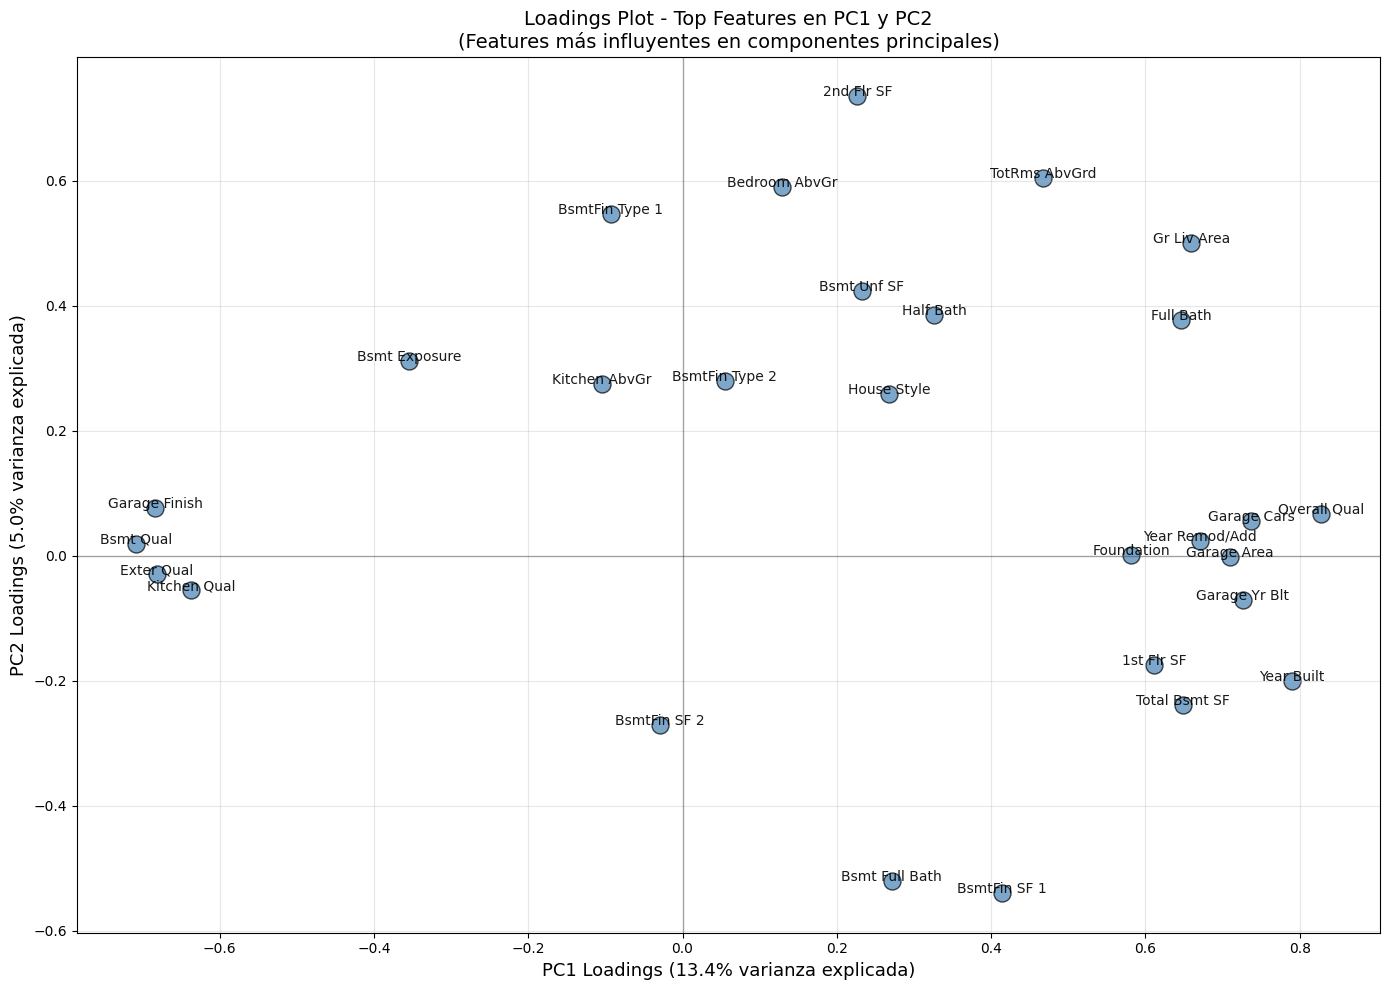


=== 💼 INTERPRETACIÓN DE NEGOCIO ===

PC1 representa principalmente (top 3):
  1. Overall Qual: Contribuye positivamente
  2. Year Built: Contribuye positivamente
  3. Garage Cars: Contribuye positivamente

💡 Interpretación: PC1 probablemente captura el 'tamaño/calidad general' de la casa

PC2 representa principalmente (top 3):
  1. 2nd Flr SF: Contribuye positivamente
  2. TotRms AbvGrd: Contribuye positivamente
  3. Bedroom AbvGr: Contribuye positivamente

💡 Interpretación: PC2 probablemente captura otra dimensión (edad, ubicación, etc.)


In [9]:
# ========== OBTENER LOADINGS ==========
print("\n=== INTERPRETACIÓN DE COMPONENTES PRINCIPALES ===")
print("Los loadings te dicen qué features originales contribuyen a cada componente")

# TODO: Obtener loadings de PC1 y PC2
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Crear DataFrame de loadings para PC1 y PC2
loadings_df = pd.DataFrame(
    loadings[:, :2],
    columns=['PC1', 'PC2'],
    index=X.columns
)

# ========== FEATURES MÁS IMPORTANTES PARA PC1 ==========
print("\n=== PC1: COMPONENTE PRINCIPAL #1 ===")
print(f"Explica {explained_variance[0]:.1%} de la varianza total")
print(f"\nTop 10 features más importantes para PC1:")
pc1_top = loadings_df['PC1'].abs().nlargest(10)
for i, (feature, loading_abs) in enumerate(pc1_top.items(), 1):
    loading_val = loadings_df.loc[feature, 'PC1']
    direction = "↑ positivo" if loading_val > 0 else "↓ negativo"
    print(f"  {i:2d}. {feature:20s}: {loading_val:+7.3f} ({direction})")

# ========== FEATURES MÁS IMPORTANTES PARA PC2 ==========
print("\n=== PC2: COMPONENTE PRINCIPAL #2 ===")
print(f"Explica {explained_variance[1]:.1%} de la varianza total")
print(f"\nTop 10 features más importantes para PC2:")
pc2_top = loadings_df['PC2'].abs().nlargest(10)
for i, (feature, loading_abs) in enumerate(pc2_top.items(), 1):
    loading_val = loadings_df.loc[feature, 'PC2']
    direction = "↑ positivo" if loading_val > 0 else "↓ negativo"
    print(f"  {i:2d}. {feature:20s}: {loading_val:+7.3f} ({direction})")

# ========== VISUALIZAR LOADINGS (solo top features para claridad) ==========
print("\n=== VISUALIZACIÓN DE LOADINGS ===")

# Seleccionar top features para visualizar (top 15 de PC1 o PC2)
top_features_pc1 = set(loadings_df['PC1'].abs().nlargest(15).index)
top_features_pc2 = set(loadings_df['PC2'].abs().nlargest(15).index)
top_features = list(top_features_pc1.union(top_features_pc2))

loadings_df_viz = loadings_df.loc[top_features]

plt.figure(figsize=(14, 10))
plt.scatter(loadings_df_viz['PC1'], loadings_df_viz['PC2'], alpha=0.7, s=150, c='steelblue', edgecolors='black')

# Anotar features
for feature in loadings_df_viz.index:
    plt.annotate(feature, 
                (loadings_df_viz.loc[feature, 'PC1'], loadings_df_viz.loc[feature, 'PC2']), 
                fontsize=10, alpha=0.9, ha='center')

plt.xlabel(f'PC1 Loadings ({explained_variance[0]:.1%} varianza explicada)', fontsize=13)
plt.ylabel(f'PC2 Loadings ({explained_variance[1]:.1%} varianza explicada)', fontsize=13)
plt.title('Loadings Plot - Top Features en PC1 y PC2\n(Features más influyentes en componentes principales)', fontsize=14)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=1)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3, linewidth=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ========== INTERPRETACIÓN DE NEGOCIO ==========
print("\n=== 💼 INTERPRETACIÓN DE NEGOCIO ===")
print("\nPC1 representa principalmente (top 3):")
for i, (feature, loading_abs) in enumerate(loadings_df['PC1'].abs().nlargest(3).items(), 1):
    loading_val = loadings_df.loc[feature, 'PC1']
    direction = "positivamente" if loading_val > 0 else "negativamente"
    print(f"  {i}. {feature}: Contribuye {direction}")

print("\n💡 Interpretación: PC1 probablemente captura el 'tamaño/calidad general' de la casa")

print("\nPC2 representa principalmente (top 3):")
for i, (feature, loading_abs) in enumerate(loadings_df['PC2'].abs().nlargest(3).items(), 1):
    loading_val = loadings_df.loc[feature, 'PC2']
    direction = "positivamente" if loading_val > 0 else "negativamente"
    print(f"  {i}. {feature}: Contribuye {direction}")

print("\n💡 Interpretación: PC2 probablemente captura otra dimensión (edad, ubicación, etc.)")

### Paso 2.5: Feature Selection Basada en PCA Loadings (CRÍTICO)


=== FEATURE SELECTION BASADA EN PCA LOADINGS ===
💡 En lugar de usar PC1, PC2... usaremos las features ORIGINALES
   que tienen mayor loading (peso) en los componentes principales

🔍 Analizando loadings de los primeros 39 componentes...

📊 ESTRATEGIA: Ranking de features por suma de loadings absolutos

🔝 TOP 20 FEATURES POR IMPORTANCIA EN PCA:
   1. Roof Matl                : 4.7138
   2. Functional               : 4.4919
   3. Screen Porch             : 4.4469
   4. Mo Sold                  : 4.3587
   5. Heating                  : 4.2757
   6. Bsmt Half Bath           : 4.2228
   7. Fence                    : 4.2113
   8. Land Contour             : 4.1697
   9. Sale Condition           : 4.1697
  10. Condition 2              : 4.1586
  11. Low Qual Fin SF          : 4.1478
  12. Roof Style               : 4.1321
  13. Sale Type                : 4.0840
  14. Utilities                : 4.0320
  15. Lot Config               : 4.0027
  16. Open Porch SF            : 3.9693
  17. Enclosed

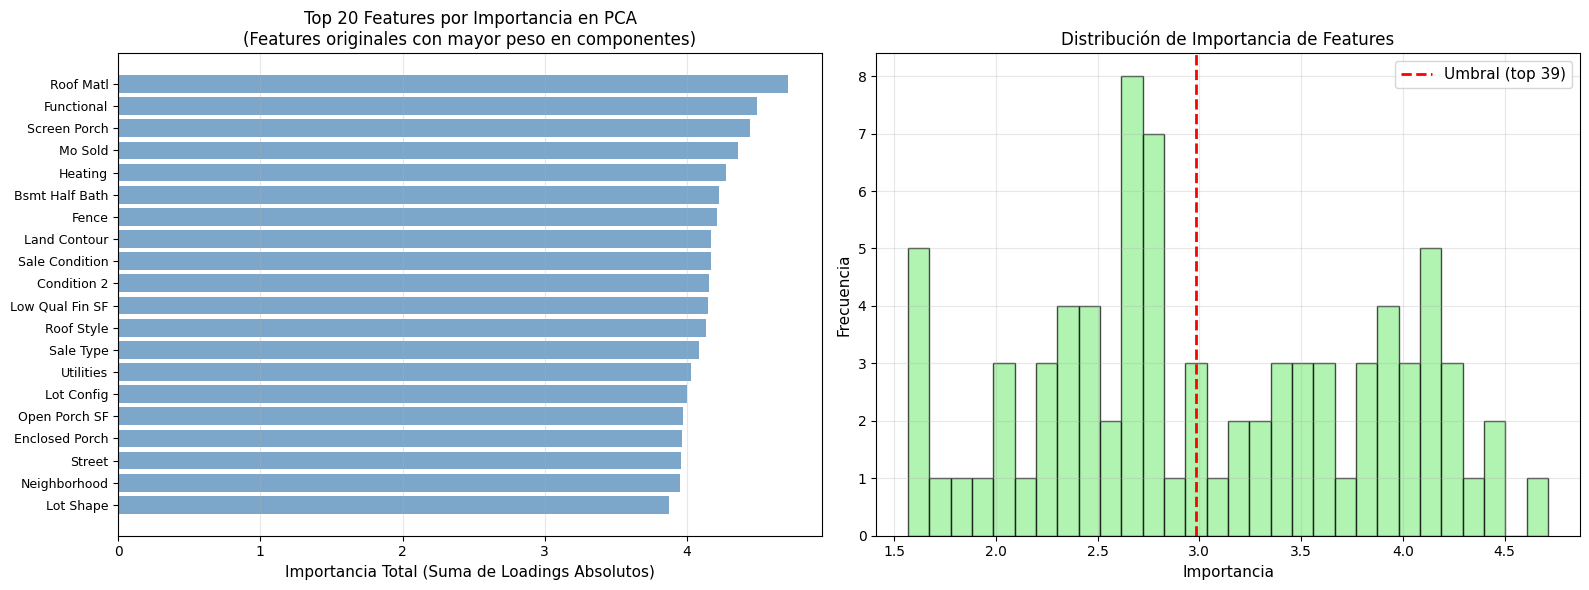


💡 INTERPRETACIÓN:
   Estas features originales son las que 'explican' los componentes principales
   Ventaja: Mantienen interpretabilidad (puedes decir 'GrLivArea importa')
   Diferencia con PCA: Usas features originales, no combinaciones lineales


In [10]:
# ========== FEATURE SELECTION BASADA EN PCA LOADINGS ==========
print("\n=== FEATURE SELECTION BASADA EN PCA LOADINGS ===")
print("💡 En lugar de usar PC1, PC2... usaremos las features ORIGINALES")
print("   que tienen mayor loading (peso) en los componentes principales")

# Decidir cuántos componentes considerar
n_top_components = 39

# Obtener loadings absolutos de todos los componentes importantes
print(f"\n🔍 Analizando loadings de los primeros {n_top_components} componentes...")

# Para cada componente, obtener las features con mayor loading absoluto
all_loadings = pca.components_[:n_top_components, :]  # Primeros n componentes

# Crear DataFrame con loadings de todos los componentes
loadings_all = pd.DataFrame(
    all_loadings.T,
    columns=[f'PC{i+1}' for i in range(n_top_components)],
    index=X.columns
)

# ========== ESTRATEGIA: SUMAR LOADINGS ABSOLUTOS ==========
# Para cada feature, sumar su importancia (loading absoluto) en todos los componentes
print("\n📊 ESTRATEGIA: Ranking de features por suma de loadings absolutos")

# TODO: Calcular importancia total de cada feature
feature_importance_from_pca = loadings_all.abs().sum(axis=1)

# Ordenar por importancia
feature_importance_from_pca = feature_importance_from_pca.sort_values(ascending=False)

print(f"\n🔝 TOP 20 FEATURES POR IMPORTANCIA EN PCA:")
for i, (feature, importance) in enumerate(feature_importance_from_pca.head(20).items(), 1):
    print(f"  {i:2d}. {feature:25s}: {importance:.4f}")

# ========== SELECCIONAR TOP-K FEATURES ==========
k = n_components_80  # Mismo número que usamos con PCA reducido

print(f"\n✅ Seleccionando top {k} features originales basadas en loadings de PCA")

# TODO: Seleccionar features
selected_features_pca = feature_importance_from_pca.head(k).index.tolist()

print(f"\n📋 Features seleccionadas ({k}):")
for i, feat in enumerate(selected_features_pca, 1):
    print(f"  {i:2d}. {feat}")

# ========== PREPARAR DATASET CON FEATURES SELECCIONADAS ==========
X_pca_selected = X_scaled[:, X.columns.isin(selected_features_pca)]

print(f"\n✅ Dataset con features seleccionadas por PCA:")
print(f"   Shape: {X_pca_selected.shape}")
print(f"   Reducción: {X.shape[1]} → {X_pca_selected.shape[1]} features")

# ========== VISUALIZAR COMPARACIÓN ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 features por importancia PCA
ax1.barh(range(20), feature_importance_from_pca.head(20).values, color='steelblue', alpha=0.7)
ax1.set_yticks(range(20))
ax1.set_yticklabels(feature_importance_from_pca.head(20).index, fontsize=9)
ax1.set_xlabel('Importancia Total (Suma de Loadings Absolutos)', fontsize=11)
ax1.set_title('Top 20 Features por Importancia en PCA\n(Features originales con mayor peso en componentes)', fontsize=12)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Distribución de importancias
ax2.hist(feature_importance_from_pca, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.set_xlabel('Importancia', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución de Importancia de Features', fontsize=12)
ax2.axvline(feature_importance_from_pca.iloc[k-1], color='red', linestyle='--', 
            label=f'Umbral (top {k})', linewidth=2)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETACIÓN:")
print("   Estas features originales son las que 'explican' los componentes principales")
print("   Ventaja: Mantienen interpretabilidad (puedes decir 'GrLivArea importa')")
print("   Diferencia con PCA: Usas features originales, no combinaciones lineales")

### Paso 2.6: Evaluación de Performance con REGRESIÓN (RMSE y R²)

In [11]:
from sklearn.ensemble import RandomForestRegressor  # ⚠️ REGRESSOR, no Classifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')  # Suprimir warnings de convergencia

# ========== MODELO BASELINE: TODAS LAS FEATURES ORIGINALES ==========
print("\n=== EVALUACIÓN DE PERFORMANCE: PCA vs ORIGINAL ===")
print("⏱️ Esto puede tomar 1-2 minutos (cross-validation con 80 features)...\n")

# TODO: Evaluar modelo con datos originales
print("🔄 Evaluando modelo con features originales...")
rf_original = RandomForestRegressor(
    random_state=42, 
    n_estimators=100,
    max_depth=15,
    n_jobs=-1             # Usar todos los cores
)

# Usar neg_mean_squared_error y neg_mean_absolute_error para CV
scores_mse_original = -cross_val_score(rf_original, X_scaled, y, cv=5, 
                                        scoring='neg_mean_squared_error', n_jobs=-1)
scores_r2_original = cross_val_score(rf_original, X_scaled, y, cv=5, 
                                     scoring='r2', n_jobs=-1)

rmse_original = np.sqrt(scores_mse_original)

print(f"\n✅ BASELINE - Features Originales ({X.shape[1]} features):")
print(f"   RMSE: ${rmse_original.mean():,.0f} ± ${rmse_original.std():,.0f}")
print(f"   R²:   {scores_r2_original.mean():.4f} ± {scores_r2_original.std():.4f}")
print(f"   Scores RMSE: {[f'${x:,.0f}' for x in rmse_original]}")

# ========== MODELO CON PCA (80% VARIANZA) ==========
print(f"\n🔄 Evaluando modelo con PCA ({n_components_80} componentes)...")

# TODO: Aplicar PCA reducido
pca_reduced = PCA(n_components=n_components_80)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

print(f"✅ PCA transformado: {X.shape[1]} → {X_pca_reduced.shape[1]} features")

# Evaluar con PCA
rf_pca = RandomForestRegressor(
    random_state=42, 
    n_estimators=100, 
    max_depth=15,
    n_jobs=-1
)

scores_mse_pca = -cross_val_score(rf_pca, X_pca_reduced, y, cv=5, 
                                   scoring='neg_mean_squared_error', n_jobs=-1)
scores_r2_pca = cross_val_score(rf_pca, X_pca_reduced, y, cv=5, 
                                scoring='r2', n_jobs=-1)

rmse_pca = np.sqrt(scores_mse_pca)

print(f"\n✅ PCA - Componentes Reducidos ({n_components_80} componentes):")
print(f"   RMSE: ${rmse_pca.mean():,.0f} ± ${rmse_pca.std():,.0f}")
print(f"   R²:   {scores_r2_pca.mean():.4f} ± {scores_r2_pca.std():.4f}")
print(f"   Scores RMSE: {[f'${x:,.0f}' for x in rmse_pca]}")

# ========== MODELO CON FEATURES SELECCIONADAS POR PCA LOADINGS ==========
print(f"\n🔄 Evaluando modelo con features originales seleccionadas por PCA loadings...")

rf_pca_selected = RandomForestRegressor(
    random_state=42, 
    n_estimators=100, 
    max_depth=15,
    n_jobs=-1
)

scores_mse_pca_selected = -cross_val_score(rf_pca_selected, X_pca_selected, y, cv=5, 
                                             scoring='neg_mean_squared_error', n_jobs=-1)
scores_r2_pca_selected = cross_val_score(rf_pca_selected, X_pca_selected, y, cv=5, 
                                          scoring='r2', n_jobs=-1)

rmse_pca_selected = np.sqrt(scores_mse_pca_selected)

print(f"\n✅ PCA Loadings - Features Originales Seleccionadas ({len(selected_features_pca)} features):")
print(f"   RMSE: ${rmse_pca_selected.mean():,.0f} ± ${rmse_pca_selected.std():,.0f}")
print(f"   R²:   {scores_r2_pca_selected.mean():.4f} ± {scores_r2_pca_selected.std():.4f}")
print(f"   Scores RMSE: {[f'${x:,.0f}' for x in rmse_pca_selected]}")

# ========== ANÁLISIS COMPARATIVO ==========
print(f"\n" + "="*80)
print(f"{'COMPARACIÓN: ORIGINAL vs PCA vs PCA LOADINGS':^80}")
print(f"="*80)

reduction_pct = (1 - n_components_80 / X.shape[1]) * 100
rmse_diff_pca = rmse_pca.mean() - rmse_original.mean()
rmse_diff_pca_selected = rmse_pca_selected.mean() - rmse_original.mean()
r2_diff_pca = scores_r2_pca.mean() - scores_r2_original.mean()
r2_diff_pca_selected = scores_r2_pca_selected.mean() - scores_r2_original.mean()

print(f"\n📊 REDUCCIÓN DIMENSIONAL:")
print(f"   Original: {X.shape[1]} features")
print(f"   PCA: {X.shape[1]} → {n_components_80} componentes ({reduction_pct:.1f}% reducción)")
print(f"   PCA Loadings: {X.shape[1]} → {len(selected_features_pca)} features originales ({reduction_pct:.1f}% reducción)")
print(f"   Varianza retenida (PCA): {pca_reduced.explained_variance_ratio_.sum():.1%}")

print(f"\n📊 PERFORMANCE COMPARATIVO:")
print(f"\n   {'Método':<25s} {'RMSE':>15s} {'R²':>10s} {'Features':>10s}")
print(f"   {'-'*25} {'-'*15} {'-'*10} {'-'*10}")
print(f"   {'Original':<25s} ${rmse_original.mean():>14,.0f} {scores_r2_original.mean():>10.4f} {X.shape[1]:>10d}")
print(f"   {'PCA Componentes':<25s} ${rmse_pca.mean():>14,.0f} {scores_r2_pca.mean():>10.4f} {n_components_80:>10d}")
print(f"   {'PCA Loadings (Originales)':<25s} ${rmse_pca_selected.mean():>14,.0f} {scores_r2_pca_selected.mean():>10.4f} {len(selected_features_pca):>10d}")

print(f"\n📊 DIFERENCIAS VS ORIGINAL:")
print(f"   PCA Componentes:  RMSE {rmse_diff_pca:+,.0f} ({(rmse_diff_pca/rmse_original.mean())*100:+.1f}%) | R² {r2_diff_pca:+.4f}")
print(f"   PCA Loadings:     RMSE {rmse_diff_pca_selected:+,.0f} ({(rmse_diff_pca_selected/rmse_original.mean())*100:+.1f}%) | R² {r2_diff_pca_selected:+.4f}")

# Interpretación
print(f"\n💡 INTERPRETACIÓN:")
print(f"\n   🔵 PCA Componentes (PC1, PC2...):")
if rmse_pca.mean() < rmse_original.mean() * 1.05:
    print(f"      ✅ Mantiene performance similar con {reduction_pct:.0f}% reducción")
    print(f"      ⚠️ Pero: Componentes son combinaciones lineales (menos interpretables)")
else:
    print(f"      ⚠️ Pierde precisión significativa ({(rmse_diff_pca/rmse_original.mean())*100:.1f}%)")

print(f"\n   🟢 PCA Loadings (Features originales):")
if rmse_pca_selected.mean() < rmse_original.mean() * 1.05:
    print(f"      ✅ Mantiene performance similar con {reduction_pct:.0f}% reducción")
    print(f"      ✅ Plus: Usa features originales (interpretables)")
else:
    print(f"      ⚠️ Pierde precisión ({(rmse_diff_pca_selected/rmse_original.mean())*100:.1f}%)")

print(f"\n   💼 PARA NEGOCIO:")
print(f"      - PCA Componentes: Mejor para modelos 'black box' donde solo importa precisión")
print(f"      - PCA Loadings: Mejor para negocio (puedes decir 'GrLivArea es importante')")


=== EVALUACIÓN DE PERFORMANCE: PCA vs ORIGINAL ===
⏱️ Esto puede tomar 1-2 minutos (cross-validation con 80 features)...

🔄 Evaluando modelo con features originales...

✅ BASELINE - Features Originales (81 features):
   RMSE: $26,308 ± $4,339
   R²:   0.8888 ± 0.0309
   Scores RMSE: ['$27,395', '$20,511', '$27,418', '$33,190', '$23,025']

🔄 Evaluando modelo con PCA (39 componentes)...
✅ PCA transformado: 81 → 39 features

✅ PCA - Componentes Reducidos (39 componentes):
   RMSE: $26,715 ± $4,125
   R²:   0.8850 ± 0.0323
   Scores RMSE: ['$25,623', '$22,249', '$27,112', '$34,320', '$24,271']

🔄 Evaluando modelo con features originales seleccionadas por PCA loadings...

✅ PCA Loadings - Features Originales Seleccionadas (39 features):
   RMSE: $41,773 ± $3,804
   R²:   0.7229 ± 0.0340
   Scores RMSE: ['$43,784', '$37,411', '$38,927', '$48,092', '$40,650']

                  COMPARACIÓN: ORIGINAL vs PCA vs PCA LOADINGS                  

📊 REDUCCIÓN DIMENSIONAL:
   Original: 81 features
 

## Parte 3: Feature Selection - Filter Methods


=== FILTER METHOD: F-TEST (ANOVA) ===
F-test mide la relación lineal entre cada feature y el target (SalePrice)

Seleccionando top 39 features con F-test...

✅ Features seleccionadas por F-test (39):
   1. PID
   2. Lot Frontage
   3. Lot Area
   4. Lot Shape
   5. Neighborhood
   6. Overall Qual
   7. Year Built
   8. Year Remod/Add
   9. Roof Style
  10. Mas Vnr Type
  11. Mas Vnr Area
  12. Exter Qual
  13. Foundation
  14. Bsmt Qual
  15. Bsmt Exposure
  16. BsmtFin SF 1
  17. Bsmt Unf SF
  18. Total Bsmt SF
  19. Heating QC
  20. Central Air
  21. Electrical
  22. 1st Flr SF
  23. 2nd Flr SF
  24. Gr Liv Area
  25. Bsmt Full Bath
  26. Full Bath
  27. Half Bath
  28. Kitchen Qual
  29. TotRms AbvGrd
  30. Fireplaces
  31. Garage Type
  32. Garage Yr Blt
  33. Garage Finish
  34. Garage Cars
  35. Garage Area
  36. Paved Drive
  37. Wood Deck SF
  38. Open Porch SF
  39. Sale Condition

=== TOP 15 F-SCORES (Mayor correlación con SalePrice) ===
   1. Overall Qual        : 5,179
   

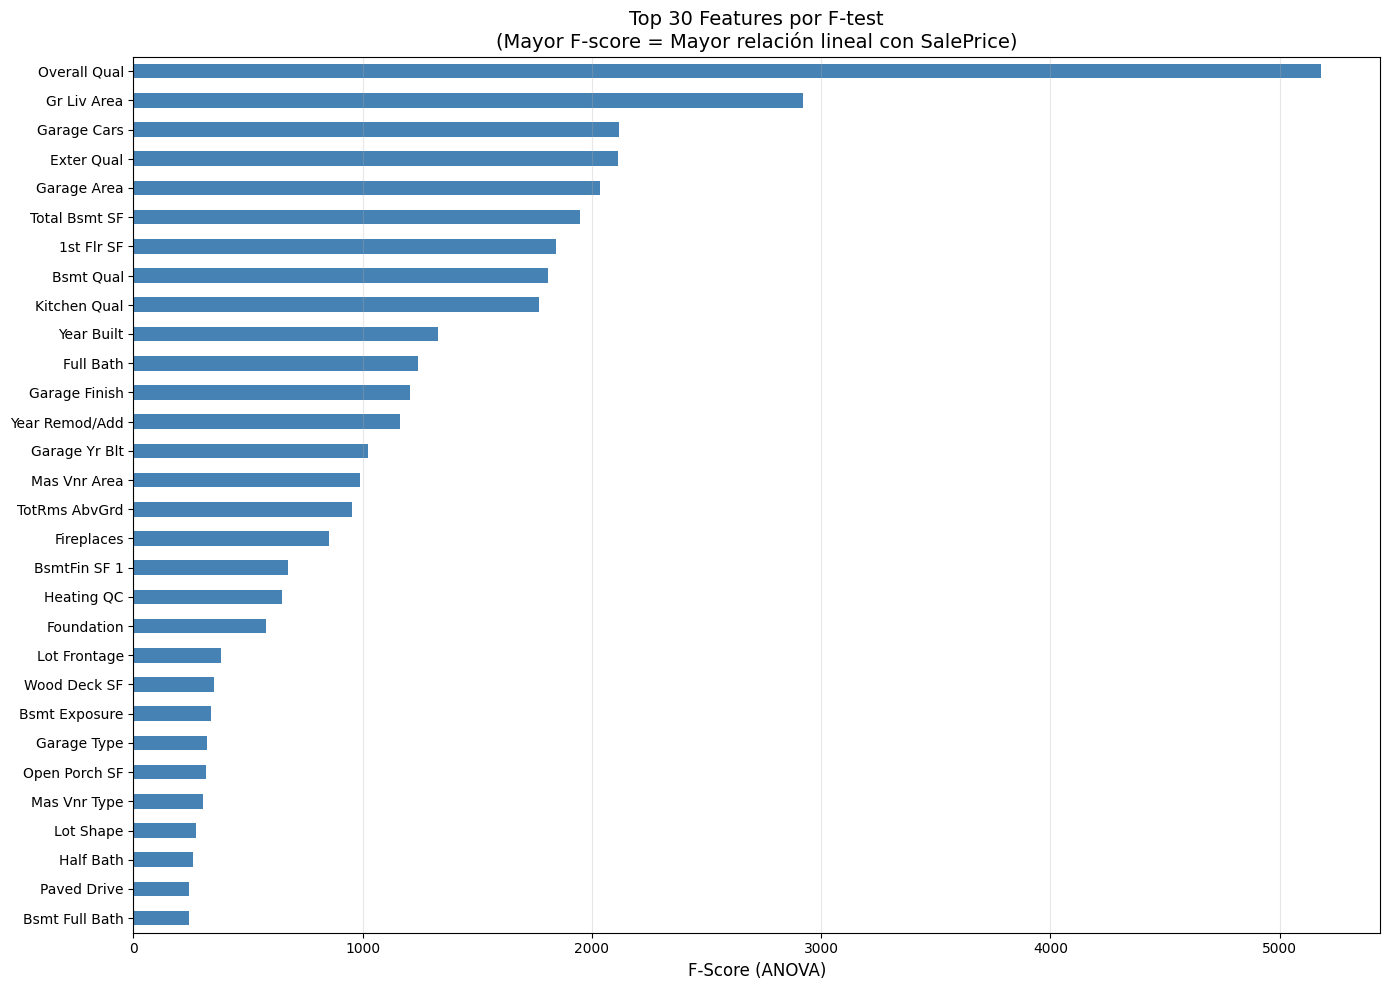

In [12]:
from sklearn.feature_selection import SelectKBest, f_regression  # ⚠️ f_regression, no f_classif

# ========== F-TEST PARA REGRESIÓN ==========
print("\n=== FILTER METHOD: F-TEST (ANOVA) ===")
print("F-test mide la relación lineal entre cada feature y el target (SalePrice)")

# TODO: Seleccionar top-k features por F-test
k = n_components_80  # Mismo número que PCA para comparación justa

print(f"\nSeleccionando top {k} features con F-test...")

selector_f = SelectKBest(f_regression, k=k)
X_filter_f = selector_f.fit_transform(X_scaled, y)

# Identificar features seleccionadas
selected_features_f = X.columns[selector_f.get_support()]
print(f"\n✅ Features seleccionadas por F-test ({k}):")
for i, feat in enumerate(selected_features_f, 1):
    print(f"  {i:2d}. {feat}")

# ========== SCORES DE F-TEST ==========
scores_f = pd.Series(selector_f.scores_, index=X.columns).sort_values(ascending=False)
print(f"\n=== TOP 15 F-SCORES (Mayor correlación con SalePrice) ===")
for i, (feat, score) in enumerate(scores_f.head(15).items(), 1):
    print(f"  {i:2d}. {feat:20s}: {score:,.0f}")

# TODO: Visualizar scores (top 30 para claridad)
plt.figure(figsize=(14, 10))
scores_f.head(30).sort_values(ascending=True).plot(kind='barh', color='steelblue')
plt.xlabel('F-Score (ANOVA)', fontsize=12)
plt.title('Top 30 Features por F-test\n(Mayor F-score = Mayor relación lineal con SalePrice)', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Paso 3.2: Filter Method - Mutual Information (Captura relaciones no-lineales)

In [13]:
from sklearn.feature_selection import mutual_info_regression  # ⚠️ mutual_info_regression, no classif

# ========== MUTUAL INFORMATION PARA REGRESIÓN ==========
print("\n=== FILTER METHOD: MUTUAL INFORMATION ===")
print("MI captura relaciones LINEALES Y NO-LINEALES (más flexible que F-test)")
print("⏱️ Esto puede tomar 30-60 segundos...")

# TODO: Seleccionar top-k features por Mutual Information
selector_mi = SelectKBest(mutual_info_regression, k=k)
X_filter_mi = selector_mi.fit_transform(X_scaled, y)

selected_features_mi = X.columns[selector_mi.get_support()]
print(f"\n✅ Features seleccionadas por Mutual Information ({k}):")
for i, feat in enumerate(selected_features_mi, 1):
    print(f"  {i:2d}. {feat}")

# Scores
scores_mi = pd.Series(selector_mi.scores_, index=X.columns).sort_values(ascending=False)
print(f"\n=== TOP 15 MI SCORES ===")
for i, (feat, score) in enumerate(scores_mi.head(15).items(), 1):
    print(f"  {i:2d}. {feat:20s}: {score:.4f}")

# ========== COMPARACIÓN: F-TEST vs MUTUAL INFORMATION ==========
common_features = set(selected_features_f) & set(selected_features_mi)
print(f"\n" + "="*70)
print(f"{'COMPARACIÓN: F-TEST vs MUTUAL INFORMATION':^70}")
print(f"="*70)
print(f"\n📊 Features en común: {len(common_features)} de {k} ({len(common_features)/k*100:.1f}% coincidencia)")

print(f"\n✅ Features comunes (ambos métodos las eligieron):")
for i, feat in enumerate(sorted(common_features), 1):
    print(f"  {i:2d}. {feat}")

print(f"\n🔵 Features SOLO en F-test:")
only_f = set(selected_features_f) - set(selected_features_mi)
for i, feat in enumerate(sorted(only_f), 1):
    print(f"  {i:2d}. {feat}")

print(f"\n🟢 Features SOLO en Mutual Information:")
only_mi = set(selected_features_mi) - set(selected_features_f)
for i, feat in enumerate(sorted(only_mi), 1):
    print(f"  {i:2d}. {feat}")

print(f"\n💡 INTERPRETACIÓN:")
if len(common_features) / k > 0.7:
    print(f"   Alta coincidencia ({len(common_features)/k*100:.0f}%) → Ambos métodos están de acuerdo")
else:
    print(f"   Baja coincidencia ({len(common_features)/k*100:.0f}%) → MI captura relaciones no-lineales diferentes")


=== FILTER METHOD: MUTUAL INFORMATION ===
MI captura relaciones LINEALES Y NO-LINEALES (más flexible que F-test)
⏱️ Esto puede tomar 30-60 segundos...

✅ Features seleccionadas por Mutual Information (39):
   1. Order
   2. PID
   3. MS SubClass
   4. MS Zoning
   5. Lot Frontage
   6. Lot Area
   7. Neighborhood
   8. Overall Qual
   9. Overall Cond
  10. Year Built
  11. Year Remod/Add
  12. Exterior 1st
  13. Exterior 2nd
  14. Mas Vnr Area
  15. Exter Qual
  16. Foundation
  17. Bsmt Qual
  18. BsmtFin Type 1
  19. BsmtFin SF 1
  20. Bsmt Unf SF
  21. Total Bsmt SF
  22. Heating QC
  23. 1st Flr SF
  24. 2nd Flr SF
  25. Gr Liv Area
  26. Full Bath
  27. Kitchen Qual
  28. TotRms AbvGrd
  29. Fireplaces
  30. Fireplace Qu
  31. Garage Type
  32. Garage Yr Blt
  33. Garage Finish
  34. Garage Cars
  35. Garage Area
  36. Wood Deck SF
  37. Open Porch SF
  38. Sale Type
  39. Sale Condition

=== TOP 15 MI SCORES ===
   1. Overall Qual        : 0.5856
   2. Neighborhood        : 0.56

### Paso 3.3: Evaluar Performance de Filter Methods

In [14]:
# ========== EVALUACIÓN: F-TEST ==========
print("\n=== EVALUANDO FILTER METHODS ===")
print("⏱️ Esto puede tomar 1-2 minutos...\n")

print("🔄 Evaluando F-test...")
rf_filter_f = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1)

scores_mse_filter_f = -cross_val_score(rf_filter_f, X_filter_f, y, cv=5, 
                                        scoring='neg_mean_squared_error', n_jobs=-1)
scores_r2_filter_f = cross_val_score(rf_filter_f, X_filter_f, y, cv=5, 
                                     scoring='r2', n_jobs=-1)
rmse_filter_f = np.sqrt(scores_mse_filter_f)

print(f"✅ F-test ({k} features):")
print(f"   RMSE: ${rmse_filter_f.mean():,.0f} ± ${rmse_filter_f.std():,.0f}")
print(f"   R²:   {scores_r2_filter_f.mean():.4f} ± {scores_r2_filter_f.std():.4f}")

# ========== EVALUACIÓN: MUTUAL INFORMATION ==========
print(f"\n🔄 Evaluando Mutual Information...")
rf_filter_mi = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1)

scores_mse_filter_mi = -cross_val_score(rf_filter_mi, X_filter_mi, y, cv=5, 
                                         scoring='neg_mean_squared_error', n_jobs=-1)
scores_r2_filter_mi = cross_val_score(rf_filter_mi, X_filter_mi, y, cv=5, 
                                      scoring='r2', n_jobs=-1)
rmse_filter_mi = np.sqrt(scores_mse_filter_mi)

print(f"✅ Mutual Information ({k} features):")
print(f"   RMSE: ${rmse_filter_mi.mean():,.0f} ± ${rmse_filter_mi.std():,.0f}")
print(f"   R²:   {scores_r2_filter_mi.mean():.4f} ± {scores_r2_filter_mi.std():.4f}")

# ========== COMPARACIÓN ACTUALIZADA ==========
print(f"\n" + "="*70)
print(f"{'COMPARACIÓN: BASELINE vs PCA vs FILTER METHODS':^70}")
print(f"="*70)

comparison_data = {
    'Método': ['Original', 'PCA', 'F-test', 'MI'],
    'N_Features': [X.shape[1], n_components_80, k, k],
    'RMSE': [rmse_original.mean(), rmse_pca.mean(), rmse_filter_f.mean(), rmse_filter_mi.mean()],
    'R²': [scores_r2_original.mean(), scores_r2_pca.mean(), scores_r2_filter_f.mean(), scores_r2_filter_mi.mean()]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df['Reducción%'] = (1 - comparison_df['N_Features'] / X.shape[1]) * 100

print(f"\n{comparison_df.to_string(index=False)}")

print(f"\n💡 OBSERVACIONES:")
print(f"   - PCA: Reduce a componentes abstractos (no interpretables)")
print(f"   - F-test & MI: Mantienen features originales (interpretables)")
print(f"   - ¿Cuál tiene mejor RMSE? ¿Vale la pena sacrificar interpretabilidad?")


=== EVALUANDO FILTER METHODS ===
⏱️ Esto puede tomar 1-2 minutos...

🔄 Evaluando F-test...
✅ F-test (39 features):
   RMSE: $26,494 ± $4,040
   R²:   0.8875 ± 0.0288

🔄 Evaluando Mutual Information...
✅ Mutual Information (39 features):
   RMSE: $26,137 ± $4,111
   R²:   0.8903 ± 0.0293

            COMPARACIÓN: BASELINE vs PCA vs FILTER METHODS            

  Método  N_Features         RMSE       R²  Reducción%
Original          81 26307.644720 0.888825    0.000000
     PCA          39 26715.126553 0.884999   51.851852
  F-test          39 26494.415957 0.887486   51.851852
      MI          39 26136.649047 0.890305   51.851852

💡 OBSERVACIONES:
   - PCA: Reduce a componentes abstractos (no interpretables)
   - F-test & MI: Mantienen features originales (interpretables)
   - ¿Cuál tiene mejor RMSE? ¿Vale la pena sacrificar interpretabilidad?
